### [Getting started] Learning to see space as numbers
### [시작하며] 공간을 숫자로 인식하기

This is the starting point of the tutorial: learning how to turn "space" into
numbers a computer can work with. We'll load Hiroshima City's administrative
boundaries, population, and bus/rail stop locations with Python and GeoPandas,
and clean them into one analysis-ready dataset.

이 튜토리얼의 출발점이다: "공간"을 컴퓨터가 다룰 수 있는 숫자로 바꾸는 법을
배운다. 히로시마시의 행정구역 경계, 인구, 버스/철도 정류장 위치를 Python과
GeoPandas로 불러와 하나의 분석용 데이터셋으로 정제한다.

Beyond just reading files, we'll practice the full preprocessing workflow a
real spatial analysis needs: unifying coordinate reference systems (CRS),
spatial joins, and aggregating by administrative area. The question we're
answering with data for the first time: "where are stops clustered, and which
areas are relatively empty?"

단순히 파일을 읽는 수준을 넘어, 실제 공간분석에 필요한 전처리 전 과정을
연습한다: 좌표계(CRS) 통일, 공간조인, 행정구역 단위 집계. 데이터로 처음
확인하는 질문은 "정류장은 어디에 몰려 있고, 어떤 지역은 상대적으로 비어
있는가?"이다.

By the end you'll understand the flow: raw data -> point geometry from
coordinates -> spatial join with administrative boundaries -> per-area facility
counts -> choropleth visualization.

이 과정을 마치면 다음 흐름을 이해하게 된다: 원시 데이터 -> 좌표 기반 포인트
생성 -> 행정구역 경계와 공간조인 -> 구역별 시설 수 집계 -> 단계구분도 시각화.

### Pandas
- A data-analysis library for loading and organizing table-shaped (DataFrame) data efficiently
- The go-to tool for handling missing values, sorting, group aggregation, and merging
- Supports CSV, Excel, databases, and many other formats
- Best suited for general analysis of numeric and categorical data

### Pandas
- 표 형태(DataFrame) 데이터를 효율적으로 불러오고 정리하는 데이터 분석 라이브러리
- 결측치 처리, 정렬, 그룹 집계, 병합 등 기본 EDA 작업에 가장 많이 사용됨
- CSV·엑셀·데이터베이스 등 다양한 데이터 포맷을 지원
- 수치·범주형 데이터 중심의 일반 데이터 분석에 적합

### GeoPandas
- A spatial-data library that adds spatial information (geometry) on top of Pandas
- Reads GIS files like shp/geojson directly and can render them as maps
- Provides spatial operations: CRS conversion, spatial joins, buffers, area/distance calculations
- Specialized for administrative-area, transportation, and environmental spatial analysis

### GeoPandas
- Pandas에 공간 정보(geometry)를 결합한 공간 데이터 전용 라이브러리
- shp·geojson 등 GIS 파일을 바로 읽고 지도 형태로 시각화 가능
- 좌표계(CRS) 변환, 공간조인, 버퍼·면적·거리 계산 등 공간 연산 제공
- 행정구역, 교통, 환경 등 공간 기반 분석에 특화됨

In [1]:
# Install the GeoPandas library
# GeoPandas 라이브러리 설치

%pip install geopandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os              # File/folder path handling
                        # 파일·폴더 경로 처리용
import warnings        # Warning message control
                        # 경고 메시지 제어용
warnings.filterwarnings("ignore")  # hide non-essential warnings / 불필요한 경고 숨기기

import pandas as pd    # table-shaped data processing / 표 형태 데이터 처리
import numpy as np     # numeric computation / 수치 계산 처리
import matplotlib.pyplot as plt  # chart visualization / 그래프 시각화
import geopandas as gpd  # spatial (map) data processing / 공간(지도) 데이터 처리

In [3]:
import matplotlib.font_manager as fm
import matplotlib as mpl

# A Japanese-capable font is required for place names (kanji/kana) to render
# in matplotlib. Yu Gothic ships with Windows 10/11; Hiragino Sans covers
# macOS. Adjust if running somewhere else.
# 지명(한자/가나)이 matplotlib에서 깨지지 않으려면 일본어를 지원하는 폰트가
# 필요하다. Yu Gothic은 Windows 10/11 기본 폰트, Hiragino Sans는 macOS용이다.
# 다른 환경에서 실행한다면 폰트를 바꿔야 할 수 있다.
try:
    mpl.rcParams["font.family"] = "Yu Gothic"       # Windows
except Exception:
    mpl.rcParams["font.family"] = "Hiragino Sans"   # Mac

mpl.rcParams["axes.unicode_minus"] = False

### 0. Folder setup / 0. 폴더 구조 설정

#### Data sources
- Administrative boundary + registered population (small-area statistics): e-Stat, https://www.e-stat.go.jp/gis
- Bus stop locations: KSJ (National Land Numerical Information) P11, https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-P11.html
- Rail / streetcar station locations: KSJ N02, https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N02.html

#### 데이터 출처
- 행정구역 경계 + 등록인구(소지역 통계): e-Stat, https://www.e-stat.go.jp/gis
- 버스정류장 위치정보: 国土数値情報(KSJ) P11, https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-P11.html
- 철도/노면전차역 위치정보: 国土数値情報(KSJ) N02, https://nlftp.mlit.go.jp/ksj/gml/datalist/KsjTmplt-N02.html

In [4]:
BASE_DIR = os.getcwd()                           # current working directory / 현재 작업 중인 기본 폴더 경로

DATA_DIR = os.path.join(BASE_DIR, "data", "hiroshima")  # data folder / 데이터 저장 폴더
OUT_DIR  = os.path.join(BASE_DIR, "outputs")             # results folder / 결과 파일 저장 폴더

os.makedirs(DATA_DIR, exist_ok=True)             # create data folder if missing / data 폴더가 없으면 생성
os.makedirs(OUT_DIR, exist_ok=True)              # create outputs folder if missing / outputs 폴더가 없으면 생성

### 1. Utility functions / 1. 유틸 함수 설정

In [5]:
def read_csv_safely(path):
    # Try UTF-8 first
    # 먼저 UTF-8 인코딩으로 읽어본다
    try:
        return pd.read_csv(path, encoding="utf-8")
    # If that fails, retry with Shift-JIS (common for Japanese government CSVs)
    # 실패하면 Shift-JIS로 재시도 (일본 정부 CSV에서 흔함)
    except UnicodeDecodeError:
        return pd.read_csv(path, encoding="shift_jis")

In [6]:
def to_num(s):
    # Coerce a string/mixed column to numeric; anything unconvertible becomes NaN
    # 문자열이나 섞여 있는 값을 숫자형으로 변환하고, 변환할 수 없는 값은 NaN으로 처리
    return pd.to_numeric(s, errors="coerce")

In [7]:
def norm_nm(x):
    if pd.isna(x):
        return None

    s = str(x).strip()
    s = s.replace("\u00A0", " ")
    s = " ".join(s.split())

    # Full-width digits/alphabet (１２３ＡＢＣ) show up inconsistently across
    # Japanese government open-data sources -- normalize to half-width so the
    # same place name matches across files.
    # 일본 공공데이터에는 전각 숫자/알파벳(１２３ＡＢＣ)이 출처마다 다르게
    # 섞여 나온다 -- 반각으로 통일해야 다른 파일 간 지명 매칭이 일치한다.
    zen = "０１２３４５６７８９ＡＢＣＤＥＦＧＨＩＪＫＬＭＮＯＰＱＲＳＴＵＶＷＸＹＺ"
    han = "0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZ"
    s = s.translate(str.maketrans(zen, han))

    return s

In [8]:
def ensure_crs(gdf, epsg):
    # Check that the GeoDataFrame actually has a CRS set
    # GeoDataFrame에 좌표계(CRS)가 설정되어 있는지 확인
    if gdf.crs is None:
        raise ValueError("Administrative boundary layer has no CRS / 행정구역 경계 레이어 CRS 없음")

    # Reproject to the requested EPSG code
    # 지정한 EPSG 좌표계로 변환하여 반환
    return gdf.to_crs(epsg=epsg)

### 2. Administrative boundary and registered population
### 2. 행정구역 경계 및 등록인구

In the Seoul version of this course, the administrative boundary (a
Shapefile) and the registered population (a separate multi-header CSV) were
two different files from two different agencies, joined by place name later
in the notebook. Japan's e-Stat small-area statistics ship differently: one
file already carries the boundary geometry *and* the population/household
counts together, at chome (town) level.

서울 버전 강의에서는 행정구역 경계(Shapefile)와 등록인구(다단헤더 CSV)가
서로 다른 기관의 별개 파일이었고, 노트북 뒷부분에서 지역명으로 매칭해
병합했다. 일본 e-Stat의 소지역 통계는 구조가 다르다 -- 경계 geometry와
인구·세대수가 처음부터 町丁목(마치) 단위로 한 파일에 함께 들어 있다.

That's a real difference in how the two governments publish open data, not a
shortcut we're taking -- worth noticing, since real projects constantly run
into "the new data source isn't shaped like the old one."

이건 우리가 지름길을 택한 게 아니라 두 정부의 오픈데이터 발행 방식이 실제로
다른 것이다 -- 실무에서는 "새 데이터 출처가 이전과 다른 구조"인 경우를 계속
마주치므로 눈여겨볼 만하다.

In [9]:
ADMIN_GPKG = os.path.join(DATA_DIR, "hiroshima_city_admin.gpkg")  # boundary + population, combined
                                                                    # 경계 + 인구, 한 파일에 결합됨

ADMIN_COL_ID = "KEY_CODE"    # chome code column / 町丁목 코드 컬럼명
ADMIN_COL_NM = "region_nm"   # chome name column (already renamed on fetch) / 町丁목 이름 컬럼명 (수집 시 이미 리네임됨)

In [10]:
gdf_admin = gpd.read_file(ADMIN_GPKG)  # read the boundary+population layer / 경계+인구 레이어 읽기
gdf_admin = gdf_admin[[ADMIN_COL_ID, ADMIN_COL_NM, "ward_nm", "pop", "households", "geometry"]].copy()
                                        # keep only the columns we need / 필요한 컬럼만 선택
gdf_admin.rename(columns={ADMIN_COL_ID: "region_id", "pop": "population"}, inplace=True)
                                        # standardize column names / 컬럼 이름을 표준 형식으로 변경
gdf_admin.head()

,region_id,region_nm,ward_nm,population,households,geometry
0,341010430,白島北町,広島市中区,1969,1160,"POLYGON ((132.46616 34.41149, 132.46619 34.411..."
1,341010440,白島中町,広島市中区,1210,660,"POLYGON ((132.46597 34.40715, 132.46608 34.407..."
2,341010450,白島九軒町,広島市中区,1408,797,"POLYGON ((132.46956 34.40592, 132.46947 34.405..."
3,341010460,東白島町,広島市中区,3918,2217,"POLYGON ((132.46468 34.40715, 132.46475 34.407..."
4,341010470,西白島町,広島市中区,2983,1876,"POLYGON ((132.46186 34.40338, 132.46185 34.403..."


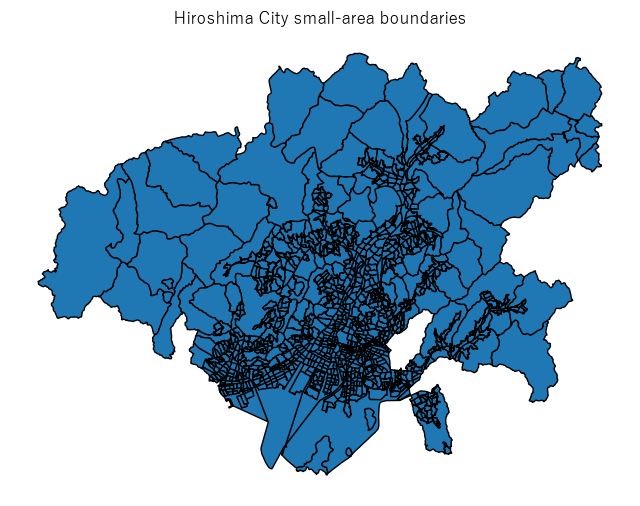

In [11]:
gdf_admin.plot(figsize=(8, 8), edgecolor="black")
plt.title("Hiroshima City small-area boundaries")
plt.axis("off")
plt.show()

In [12]:
# Normalize chome names with norm_nm (unifies whitespace/full-width digits so
# later joins match correctly)
# 지명을 norm_nm으로 정규화 (공백·전각 숫자를 통일해 이후 데이터 매칭 정확도 향상)
gdf_admin["region_nm"] = gdf_admin["region_nm"].map(norm_nm)

In [13]:
# Reproject to a metric CRS (EPSG:6670, JGD2000 / Plane Rectangular CS III --
# Hiroshima Prefecture's zone) so area, distance, and buffer calculations are
# all done in metres, not degrees.
# 미터 단위 좌표계(EPSG:6670, JGD2000 평면직각좌표계 -- 히로시마현이 속한
# 3계)로 변환한다. 이후 면적·거리·버퍼 계산을 모두 같은 좌표계, 미터 단위로
# 처리하기 위함이다.
gdf_admin = ensure_crs(gdf_admin, 6670)

In [14]:
gdf_admin["area_km2"] = gdf_admin.geometry.area / 1e6  # m^2 -> km^2 / m^2를 km^2로 변환
gdf_admin["pop_density"] = gdf_admin["population"] / gdf_admin["area_km2"]  # people per km^2 / km^2당 인구
gdf_admin[["region_nm", "ward_nm", "population", "area_km2", "pop_density"]].head()

,region_nm,ward_nm,population,area_km2,pop_density
0,白島北町,広島市中区,1969,0.275951,7135.318900
1,白島中町,広島市中区,1210,0.095383,12685.682964
2,白島九軒町,広島市中区,1408,0.162421,8668.849930
3,東白島町,広島市中区,3918,0.214768,18242.922783
4,西白島町,広島市中区,2983,0.263790,11308.246167


In [15]:
ADMIN_FILE = os.path.join(DATA_DIR, "hiroshima_admin_pop.csv")  # save the combined table / 결합 테이블 저장 경로
gdf_admin.drop(columns="geometry").to_csv(ADMIN_FILE, index=False, encoding="utf-8-sig")
                                        # drop geometry for the plain CSV export / CSV로는 geometry 제외하고 저장

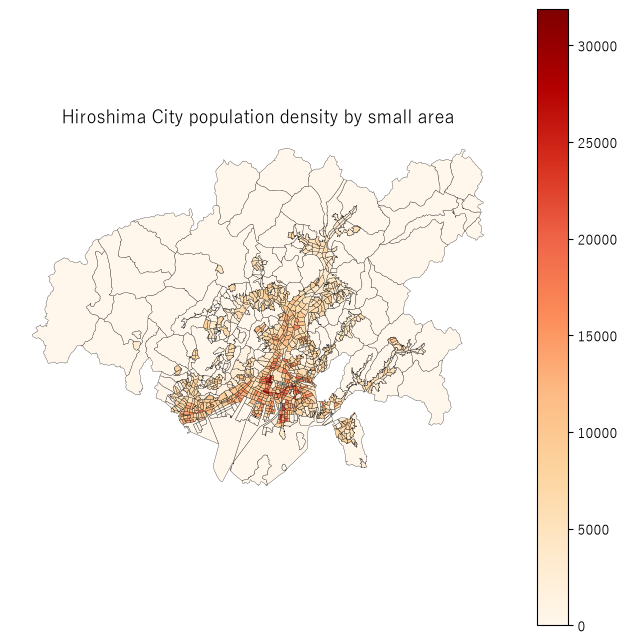

In [16]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_admin.plot(
    column="pop_density",      # color by this column / 색칠 기준 컬럼 (인구밀도)
    cmap="OrRd",                # light -> dark palette / 색상 팔레트 (연한색 → 진한색)
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
)

plt.title("Hiroshima City population density by small area", fontsize=13)
plt.axis("off")
plt.show()

#### Coordinate Reference Systems (CRS)

- A reference system for expressing a location on Earth as flat coordinates
- Broadly split into geographic (lat/lon) and projected coordinate systems
- Spatial layers with different CRSs must be reprojected to a common one before analysis
- CRS choice materially affects the accuracy of distance, area, and buffer calculations
- The right CRS depends on the analysis goal -- there's no single "correct" one

#### 좌표계(CRS, Coordinate Reference System)

- 지구상의 위치를 평면 좌표로 표현하기 위한 기준 체계
- 위도·경도 좌표계와 투영 좌표계로 크게 구분됨
- 공간 데이터 간의 좌표계가 다르면 반드시 변환 후 분석해야 함
- 거리, 면적, 버퍼 계산의 정확도는 좌표계 선택에 크게 영향을 받음
- GIS 분석에서는 "분석 목적에 맞는 좌표계"를 선택하는 것이 중요

#### EPSG:4326 (WGS84, latitude/longitude)

- The global-standard geographic CRS, expressed in latitude and longitude
- Units are degrees, so it's unsuitable for distance/area calculations
- The default CRS for GPS, map APIs, and most raw location data
- Convenient for display, but imprecise for rigorous spatial analysis

#### EPSG:4326 (WGS84, 위경도 좌표계)

- 위도(latitude)와 경도(longitude)로 위치를 표현하는 전 지구 표준 좌표계
- 단위가 '도(degree)'이기 때문에 거리·면적 계산에 부적합
- GPS, 지도 API, 대부분의 원본 위치 데이터의 기본 좌표계
- 시각화·위치 표시에는 편리하지만 정밀 공간 분석에는 부정확

#### EPSG:6670 (JGD2000 / Plane Rectangular CS III)

- A projected CRS covering Yamaguchi, Shimane, and Hiroshima prefectures
- Units are metres, so distance/area/buffer calculations are accurate
- Suited to administrative-area calculations, accessibility analysis, coverage analysis
- Japan defines 19 such zones nationwide; each region uses its own zone number

#### EPSG:6670 (JGD2000 평면직각좌표계 3계)

- 야마구치·시마네·히로시마현을 포함하는 투영 좌표계
- 단위가 '미터(m)'이므로 거리·면적·버퍼 계산에 정확
- 행정구역 면적 계산, 접근성 분석, 커버리지 분석 등에 적합
- 일본 전역에 19개 계로 나뉘어 있으며, 지역마다 자신의 계 번호를 사용

#### Practical guidance

- Loading raw data: keep it in EPSG:4326 as-is
- Before spatial analysis: standardize to EPSG:6670 (or the projected CRS for your region)
- Area/distance/buffer calculations: always run them in a projected CRS
- EPSG.io (https://epsg.io)

#### 실무 권장 원칙

- 원본 데이터 불러오기: EPSG:4326 그대로 사용
- 공간 분석 시작 전: EPSG:6670(또는 해당 지역의 투영 좌표계)로 통일
- 면적·거리·버퍼 계산은 항상 투영 좌표계에서 수행
- EPSG.io (https://epsg.io)

### 3. Bus and rail/streetcar facility aggregation
### 3. 버스 및 철도/노면전차 시설 집계

Here we turn bus-stop and station locations into spatial objects, then spatial-join
them against the administrative boundary polygons to count facilities per area.

여기서는 버스정류장과 철도역 위치를 공간 객체로 변환한 뒤, 행정구역 경계
폴리곤과의 공간 조인을 통해 각 구역별 시설 개수를 집계한다.

Unlike the Seoul version -- which built Point geometry from raw X/Y columns
in a CSV/Excel file -- KSJ's bus-stop and station layers already ship as
GIS files with geometry included. One less step, but the CRS conversion and
spatial-join logic taught here are identical.

서울 버전은 CSV/엑셀의 원본 X/Y 컬럼으로 Point geometry를 직접 만들어야
했지만, 国土数値情報(KSJ)의 버스정류장·역 레이어는 처음부터 geometry가
포함된 GIS 파일로 제공된다. 한 단계가 줄어들 뿐, 이후 배우는 좌표계 변환과
공간조인 로직은 동일하다.

In [17]:
BUS_GPKG = os.path.join(DATA_DIR, "hiroshima_city_bus_stops.gpkg")  # bus stop locations / 버스정류장 위치 파일 경로

gdf_bus = gpd.read_file(BUS_GPKG)  # already has Point geometry -- no X/Y columns to build from
                                     # 이미 Point geometry가 있어 X/Y 컬럼으로 만들 필요 없음
gdf_bus = gdf_bus.to_crs(epsg=6670)  # reproject to the metric CRS / 미터 단위 좌표계로 변환
gdf_bus[["P11_001", "geometry"]].head()  # P11_001 = stop name / P11_001 = 정류장 이름

,P11_001,geometry
0,久地,POINT (129064.928 167200.13)
1,広島北IC,POINT (133221.576 173065.299)
2,大塚駅,POINT (129056.727 160869.361)
3,広島北インター,POINT (132985.314 172286.288)
4,久地,POINT (128226.986 166051.068)


In [18]:
bus_cnt = (
    gpd.sjoin(gdf_bus, gdf_admin, how="left", predicate="within")
    # spatial join: assign each bus stop point to the small area it falls within
    # 버스정류소 포인트를 소지역 폴리곤에 공간조인 → 각 정류소에 소지역 정보 부여

    .groupby(["region_id", "region_nm"])
    # group by chome code + name / 소지역 코드 + 이름 기준으로 그룹화

    .size()
    .reset_index(name="bus_stop_cnt")
    # count bus stops per small area / 소지역별 버스정류장 개수를 집계
)

bus_cnt.head()

,region_id,region_nm,bus_stop_cnt
0,341010430,白島北町,1
1,341010450,白島九軒町,1
2,341010460,東白島町,2
3,341010470,西白島町,1
4,341010480,幟町,1


In [19]:
gdf_bus_map = gdf_admin.merge(
    bus_cnt[["region_id", "bus_stop_cnt"]],
    on="region_id",
    how="left",
)
# join the count back onto the boundary layer, on chome code
# 경계 데이터에 버스정류장 집계 결과를 소지역 코드 기준으로 병합하여 지도용 데이터 생성

gdf_bus_map["bus_stop_cnt"] = gdf_bus_map["bus_stop_cnt"].fillna(0)
# small areas with zero stops become 0, not NaN, to avoid downstream errors
# 버스정류장이 없는 소지역은 NaN 대신 0으로 채워서 이후 시각화·계산 오류 방지

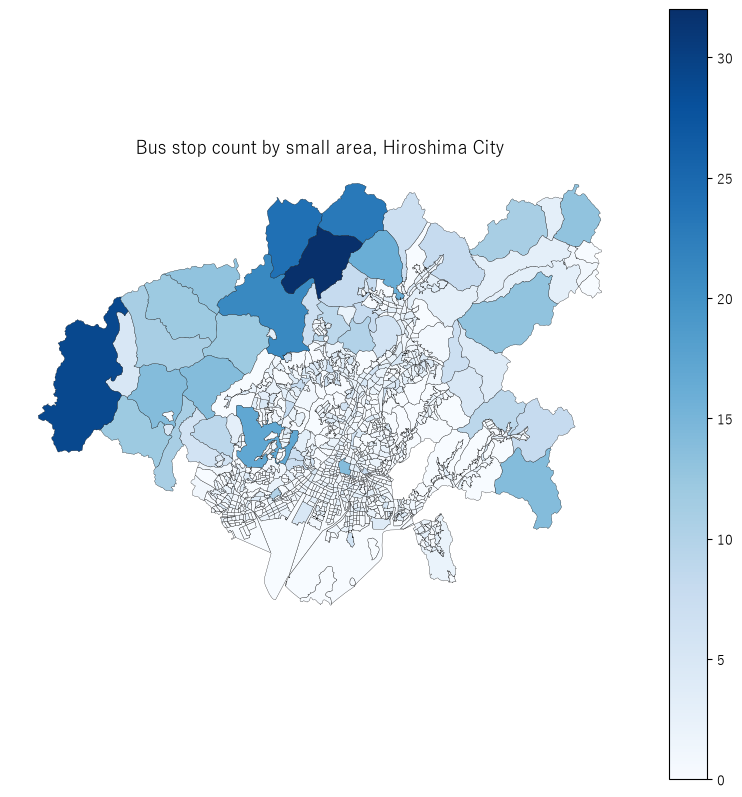

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_bus_map.plot(
    column="bus_stop_cnt",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    linewidth=0.2,
    ax=ax,
)

plt.title("Bus stop count by small area, Hiroshima City", fontsize=13)
plt.axis("off")
plt.show()

In [21]:
BUS_FILE = os.path.join(DATA_DIR, "bus_stop_cnt_by_admin.csv")  # save path / 집계 결과 저장 경로
bus_cnt.to_csv(BUS_FILE, index=False, encoding="utf-8-sig")

In [22]:
STATION_GPKG = os.path.join(DATA_DIR, "hiroshima_city_stations.gpkg")  # rail/streetcar station locations
                                                                          # 철도/노면전차역 위치 파일 경로

gdf_station = gpd.read_file(STATION_GPKG)
gdf_station[["N02_003", "N02_004", "N02_005", "geometry"]].head()
# N02_003 = line name, N02_004 = operator, N02_005 = station name
# N02_003 = 노선명, N02_004 = 사업자명, N02_005 = 역명

,N02_003,N02_004,N02_005,geometry
0,広島新交通1号線,広島高速交通,安東,"LINESTRING (132.45378 34.47469, 132.4532 34.47..."
1,広島新交通1号線,広島高速交通,城北,"LINESTRING (132.45883 34.40506, 132.45907 34.4..."
2,広島新交通1号線,広島高速交通,大町,"LINESTRING (132.4711 34.46127, 132.47034 34.46..."
3,広島新交通1号線,広島高速交通,上安,"LINESTRING (132.44543 34.47574, 132.44459 34.4..."
4,広島新交通1号線,広島高速交通,西原,"LINESTRING (132.47471 34.44299, 132.47483 34.4..."


In [23]:
# N02 station geometry is a short platform LineString (e.g. Hiroden's
# dual-track streetcar stops), not a point. Take the centroid, in a metric
# CRS, for a clean marker -- the same fix used in hiroshima_slope_case.ipynb.
# N02 역 geometry는 점이 아니라 짧은 플랫폼 선분(広電 복선 노면전차 정류장 등)
# 이다. 미터 좌표계에서 centroid를 구해 깔끔한 마커로 쓴다 --
# hiroshima_slope_case.ipynb에서 쓴 것과 같은 처리다.
gdf_station = gdf_station.to_crs(epsg=6670)
gdf_station["geometry"] = gdf_station.geometry.centroid

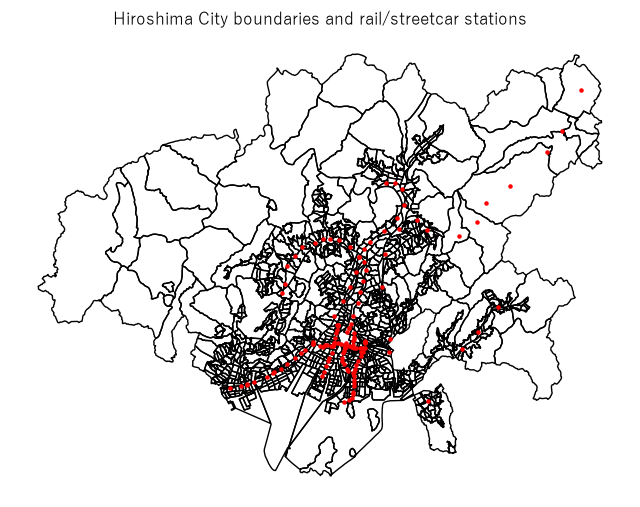

In [24]:
ax = gdf_admin.plot(edgecolor="black", facecolor="none", figsize=(8, 8))
# draw the small-area boundaries first / 행정구역 경계를 먼저 그림

gdf_station.plot(
    ax=ax,
    color="red",
    markersize=5,
)
# rail/streetcar stations as red points / 철도/노면전차역 포인트를 빨간 점으로 표시

plt.title("Hiroshima City boundaries and rail/streetcar stations")
plt.axis("off")
plt.show()

In [25]:
station_cnt = (
    gpd.sjoin(gdf_station, gdf_admin, how="left", predicate="within")
    # spatial join stations against small-area polygons
    # 역 포인트를 소지역 폴리곤에 공간조인 → 각 역이 속한 소지역 코드·이름 정보 부여

    .groupby(["region_id", "region_nm"])
    .size()
    .reset_index(name="station_cnt")
    # count stations per small area / 소지역별 역 개수를 집계
)

STATION_FILE = os.path.join(DATA_DIR, "station_cnt_by_admin.csv")
station_cnt.to_csv(STATION_FILE, index=False, encoding="utf-8-sig")

### 4. Merging processed data and building derived indicators
### 4. 가공 데이터 병합 및 파생지표

Here we merge the population, bus, and rail/streetcar tables we've built so
far into one combined table, keyed on chome code (region_id).

지금까지 개별적으로 가공한 인구, 버스, 철도/노면전차 데이터를 소지역 코드
(region_id) 기준으로 하나의 통합 테이블로 병합한다.

To correct for population-size differences, we build normalized indicators:
bus stops per 10,000 residents, and rail/streetcar stations per 10,000
residents. These go beyond a raw headcount, letting us compare accessibility
gaps between areas on equal footing -- the core metric for identifying
transit-underserved areas later.

인구 규모 차이를 보정하기 위해 인구 1만 명당 버스정류장 수, 인구 1만 명당
철도/노면전차역 수 같은 표준화 지표를 만든다. 단순 개수 비교를 넘어 지역
간 접근성 격차를 동일한 기준으로 비교할 수 있게 되며, 이는 이후 교통
취약지역을 선별하는 핵심 지표가 된다.

In [26]:
pop_n = gdf_admin[["region_id", "population", "pop_density"]].copy()
bus_n = bus_cnt[["region_id", "bus_stop_cnt"]].copy()
sub_n = station_cnt[["region_id", "station_cnt"]].copy()

df = (
    pop_n
    .merge(bus_n, on="region_id", how="left")
    .merge(sub_n, on="region_id", how="left")
)

df["bus_stop_cnt"] = df["bus_stop_cnt"].fillna(0)
df["station_cnt"] = df["station_cnt"].fillna(0)
df.head()

,region_id,population,pop_density,bus_stop_cnt,station_cnt
0,341010430,1969,7135.318900,1.0,1.0
1,341010440,1210,12685.682964,0.0,0.0
2,341010450,1408,8668.849930,1.0,0.0
3,341010460,3918,18242.922783,2.0,1.0
4,341010470,2983,11308.246167,1.0,3.0


In [27]:
gdf_map = gdf_admin.merge(
    df[["region_id", "bus_stop_cnt", "station_cnt"]],
    on="region_id",
    how="left",
)

# 93 of Hiroshima's 1,136 small areas have zero registered residents (parks,
# industrial land, the airport, etc.) -- a real characteristic of Japan's
# finer chome-level subdivision, not something Seoul's coarser 426 dongs hit.
# "Stops per 10,000 residents" is undefined with zero residents, so those
# areas get NaN here rather than a division-by-zero inf/nan silently leaking
# into the analysis.
# 히로시마 1,136개 소지역 중 93곳은 등록 인구가 0이다(공원, 공업지역, 공항
# 부지 등) -- 일본의 더 촘촘한 町丁목 단위 세분화가 만든 실제 특성으로, 서울의
# 더 굵은 426개 동에서는 마주치지 않았던 경우다. 인구가 0이면 "인구 1만명당"
# 지표 자체가 정의되지 않으므로, 0으로 나눠 나오는 inf/nan이 조용히 분석에
# 섞이지 않도록 이 지역들은 NaN으로 명시적으로 남긴다.
has_residents = gdf_map["population"] > 0
gdf_map["bus_per_10k"] = np.where(
    has_residents, gdf_map["bus_stop_cnt"] / (gdf_map["population"] / 10000), np.nan
)
gdf_map["station_per_10k"] = np.where(
    has_residents, gdf_map["station_cnt"] / (gdf_map["population"] / 10000), np.nan
)
print(f"{(~has_residents).sum()} small areas have zero population -- excluded from per-capita indicators")
print(f"인구 0인 소지역 {(~has_residents).sum()}곳 -- 1인당 지표에서 제외")
gdf_map.head()

117 small areas have zero population -- excluded from per-capita indicators
인구 0인 소지역 117곳 -- 1인당 지표에서 제외


,region_id,region_nm,ward_nm,population,households,geometry,area_km2,pop_density,bus_stop_cnt,station_cnt,bus_per_10k,station_per_10k
0,341010430,白島北町,広島市中区,1969,1160,"POLYGON ((134785.746 157517.303, 134788.752 15...",0.275951,7135.318900,1.0,1.0,5.078720,5.078720
1,341010440,白島中町,広島市中区,1210,660,"POLYGON ((134775.23 157035.337, 134786.011 157...",0.095383,12685.682964,0.0,0.0,0.000000,0.000000
2,341010450,白島九軒町,広島市中区,1408,797,"POLYGON ((135108.097 156903.63, 135099.614 156...",0.162421,8668.849930,1.0,0.0,7.102273,0.000000
3,341010460,東白島町,広島市中区,3918,2217,"POLYGON ((134656.986 157033.975, 134663.427 15...",0.214768,18242.922783,2.0,1.0,5.104645,2.552323
4,341010470,西白島町,広島市中区,2983,1876,"POLYGON ((134403.986 156611.827, 134403.3 1566...",0.263790,11308.246167,1.0,3.0,3.352330,10.056990


In [28]:
# 40% of populated small areas have exactly zero bus stops within their own
# polygon -- Hiroshima's chome subdivision is fine-grained enough that most
# residents rely on a stop in a *neighbouring* block, not their own. A plain
# 5-quantile qcut can't split a distribution where the bottom 40% of values
# are identical (it errors on duplicate bin edges). So "no stop in this
# block" gets its own explicit class, and only the small areas that do have
# a stop get quantile-split into low/medium/high.
# 인구가 있는 소지역의 40%는 자기 폴리곤 안에 버스정류장이 아예 없다 --
# 히로시마의 町丁목 세분화가 촘촘해서 대부분 주민이 '이웃' 블록의 정류장을
# 이용하기 때문이다. 하위 40%가 전부 같은 값이면 일반적인 5분위 qcut은
# 구간 경계 중복으로 에러가 난다. 그래서 "이 블록엔 정류장 없음"을 별도
# 범주로 명시하고, 정류장이 있는 소지역만 low/medium/high로 분위수 분할한다.
has_stop = gdf_map["bus_per_10k"] > 0
gdf_map["bus_class"] = pd.Series(pd.NA, index=gdf_map.index, dtype="object")
gdf_map.loc[gdf_map["bus_per_10k"] == 0, "bus_class"] = "no stop in block"
gdf_map.loc[has_stop, "bus_class"] = pd.qcut(
    gdf_map.loc[has_stop, "bus_per_10k"],
    q=3,
    labels=["low", "medium", "high"],
)

# Without an explicit order, geopandas colors categories alphabetically --
# "high" would render lightest and "no stop in block" darkest, exactly
# backwards from what the Blues gradient should mean. Force the real order.
# 순서를 명시하지 않으면 geopandas가 알파벳순으로 색을 매기는데, 그러면
# "high"가 가장 연하고 "no stop in block"이 가장 진하게 나와 Blues 그라데이션이
# 뜻하는 것과 정반대가 된다. 실제 순서를 강제로 지정한다.
gdf_map["bus_class"] = pd.Categorical(
    gdf_map["bus_class"],
    categories=["no stop in block", "low", "medium", "high"],
    ordered=True,
)

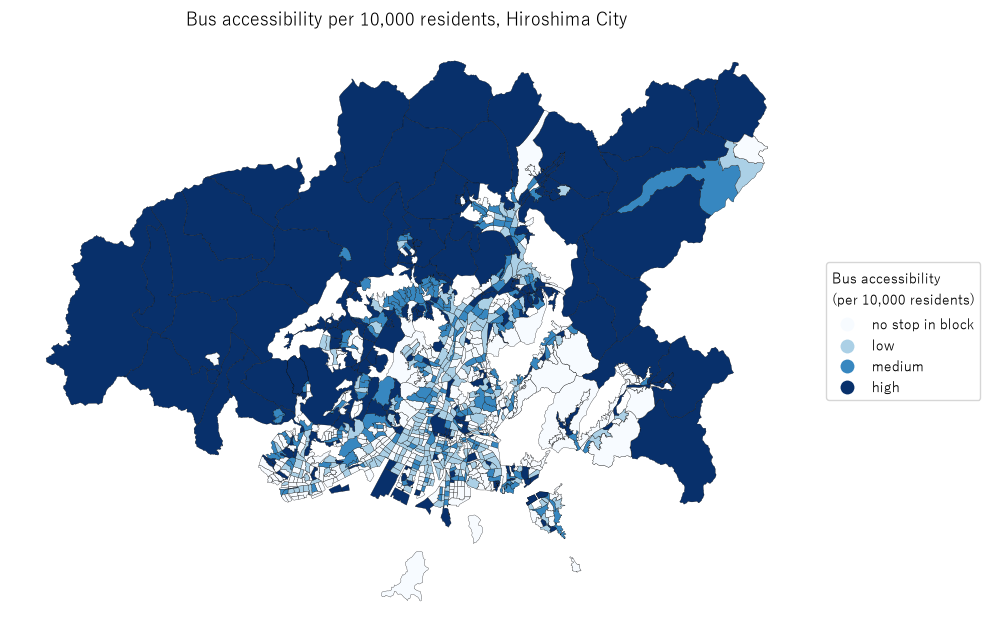

In [29]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf_map.plot(
    column="bus_class",
    cmap="Blues",
    edgecolor="black",
    linewidth=0.2,
    legend=True,
    ax=ax,
    legend_kwds={
        "title": "Bus accessibility\n(per 10,000 residents)",
        "loc": "center left",
        "bbox_to_anchor": (1.02, 0.5),  # place legend outside the map, to the right
    },
)

plt.title("Bus accessibility per 10,000 residents, Hiroshima City", fontsize=13)
plt.axis("off")
plt.tight_layout()
plt.show()

Notice the mountainous fringe wards (top and left) read as "high" -- darkest
blue -- while the dense urban core along the river delta looks patchier.
That's not because the hills are better served: a per-capita ratio like
"stops per 10,000 residents" gets inflated wherever the *denominator* is
tiny. A hillside area with 2 residents and 1 through-route stop scores
5,000 per 10k; a dense downtown block with 2,000 residents and 20 stops
scores 100. Both numbers are correct, but only one describes what a rider
actually experiences. This is the same shape of problem the areal-weighting
findings in the Seoul version were about: a number that is technically
correct can still describe the wrong thing.

산간 외곽 구(위·왼쪽)가 가장 진한 파랑, 즉 "high"로 나오는데, 언덕 지역의
서비스가 실제로 더 좋아서가 아니다. "인구 1만명당" 같은 1인당 비율은
분모(인구)가 작을수록 부풀려진다. 주민 2명에 통과노선 정류장 1개가 있는
산간 지역은 1만명당 5,000이 나오지만, 주민 2,000명에 정류장 20개가 있는
번화가는 1만명당 100이 나온다. 둘 다 계산은 맞지만, 실제 이용자 경험을
설명하는 건 후자뿐이다. 서울 버전의 면적가중 발견들과 같은 종류의 문제다 --
숫자 자체는 틀리지 않았는데 엉뚱한 것을 설명하고 있다.

In [30]:
OUT_GPKG = os.path.join(OUT_DIR, "hiroshima_eda_map.gpkg")

gdf_map.to_file(OUT_GPKG, layer="eda_map", driver="GPKG")
# save boundary + population + bus + rail + derived indicators together
# 경계 + 인구 + 버스 + 철도 + 파생지표를 포함한 공간 데이터 저장
# can be reopened directly in QGIS or GeoPandas
# QGIS, GeoPandas에서 바로 다시 불러와 지도 시각화 가능

#### Shapefile (.shp) vs. GeoPackage (.gpkg)

Shapefile and GeoPackage are both common spatial-data formats, but differ
structurally. A Shapefile layer is spread across several files (.shp, .shx,
.dbf, .prj, ...), which is awkward to manage, and it has real constraints --
a 10-character column-name limit and encoding issues with non-Latin text.
Still, as an old standard, it's widely supported across GIS software.

GeoPackage is a modern OGC-standard format that stores everything in a
single file. It supports multiple layers at once, has no column-length
limit, and defaults to UTF-8 -- handling Japanese and Korean text natively.
It performs well on large data and is much easier to manage.

Shapefile과 GeoPackage는 공간 데이터를 저장하는 대표적인 형식이지만 구조와
기능에서 큰 차이를 가진다.

Shapefile은 하나의 레이어가 여러 개의 파일(.shp, .shx, .dbf, .prj 등)로
구성되어 관리가 불편하고, 컬럼 이름 10자 제한과 비라틴 문자 인코딩 문제 등
구조적 제약이 많다. 다만 오래된 표준 형식으로 대부분의 GIS 소프트웨어에서
널리 지원된다.

GeoPackage는 하나의 파일 안에 모든 정보를 저장하는 최신 OGC 표준 형식으로,
여러 레이어를 동시에 저장할 수 있고 컬럼 길이 제한이 없으며 UTF-8 인코딩을
기본 지원해 일본어·한국어 텍스트를 그대로 다룰 수 있다. 대용량 데이터
처리 성능도 우수하고 관리가 매우 편리하다.

**Recommendation**: Shapefile for legacy-system compatibility or simple
layer hand-off; GeoPackage for teaching, research, real-world work, and
anything involving non-Latin text or combined analysis results.

**활용 권장**: Shapefile은 구형 시스템 호환이 필요하거나 단순 레이어
전달용, GeoPackage는 강의·연구·실무 전반, 비라틴 문자 데이터 포함, 복합
분석 결과 저장용.

### 5. Exploratory Data Analysis (EDA) / 5. 탐색적 데이터 분석(EDA)

#### "Do areas with low bus accessibility also have low rail/streetcar accessibility?"
#### "버스 접근성이 낮은 지역은 철도/노면전차 접근성도 낮은가?"


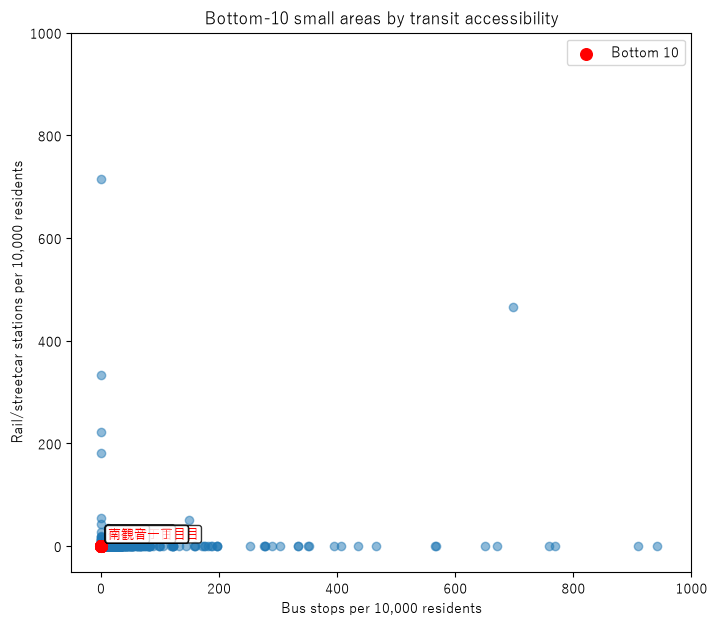

In [31]:
# ~40% of populated small areas tie at bus_per_10k == 0 (see the note above --
# most residents rely on a neighbouring block's stop). A plain ascending sort
# would pick 10 of those ties arbitrarily, so break ties by population
# descending: among equally zero-served areas, surface the ones affecting
# the most residents first -- the more useful "worst 10" for a real audience.
# 인구가 있는 소지역의 약 40%가 bus_per_10k == 0으로 동률이다(위 설명대로
# 대부분 이웃 블록의 정류장을 이용하기 때문). 그냥 오름차순 정렬만 하면 이
# 동률 중 임의의 10곳이 뽑힌다 -- 인구 내림차순으로 동률을 깨서, 똑같이
# 서비스가 없는 지역 중에서도 더 많은 주민에게 영향을 주는 곳을 먼저 보여준다.
target_top10 = gdf_map.sort_values(
    ["bus_per_10k", "station_per_10k", "population"],
    ascending=[True, True, False],
).head(10)

# A handful of very-low-population small areas have extreme per-capita
# ratios (e.g. 1 stop / 1 resident = 10,000 per 10k) that stretch the axes
# and hide the real pattern -- clip the view, not the underlying data.
# 인구가 극히 적은 소지역 몇 곳은 1인당 비율이 극단적으로 커져(예: 주민 1명에
# 정류장 1개 = 인구 1만명당 10,000) 축을 왜곡시킨다 -- 원본 데이터는 그대로
# 두고 보이는 범위만 clip한다.
plt.figure(figsize=(8, 7))
plt.scatter(
    gdf_map["bus_per_10k"],
    gdf_map["station_per_10k"],
    alpha=0.5,  # point transparency, to reduce overplotting / 점 투명도 조절 (겹침 완화)
)

# highlight the worst-10 in red
# 접근성 최하위 10곳만 빨간색으로 강조 표시
plt.scatter(
    target_top10["bus_per_10k"],
    target_top10["station_per_10k"],
    color="red",
    s=70,
    label="Bottom 10",
)

# label the worst-10 with their names
# 최하위 10곳에 지명 라벨 표시
for _, row in target_top10.iterrows():
    plt.annotate(
        row["region_nm"],
        (row["bus_per_10k"], row["station_per_10k"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        color="red",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
    )

plt.xlim(-50, 1000)   # clip the view past the small-denominator outliers / 소분모 이상치 너머는 보이는 범위에서 제외
plt.ylim(-50, 1000)
plt.xlabel("Bus stops per 10,000 residents")
plt.ylabel("Rail/streetcar stations per 10,000 residents")
plt.title("Bottom-10 small areas by transit accessibility")
plt.legend()
plt.show()

In [32]:
target_top10[[
    "region_nm",        # small area name / 소지역 이름
    "ward_nm",           # ward / 소속 구
    "population",        # total population / 총 인구
    "bus_stop_cnt",       # bus stop count / 버스정류장 개수
    "bus_per_10k",        # bus stops per 10k / 인구 1만 명당 버스정류장 수
    "station_cnt",        # station count / 역 개수
    "station_per_10k",    # stations per 10k / 인구 1만 명당 역 수
]]

,region_nm,ward_nm,population,bus_stop_cnt,bus_per_10k,station_cnt,station_per_10k
689,東原三丁目,広島市安佐南区,4172,0.0,0.0,0.0,0.0
626,東野二丁目,広島市安佐南区,3064,0.0,0.0,0.0,0.0
496,井口五丁目,広島市西区,2707,0.0,0.0,0.0,0.0
41,東千田町一丁目,広島市中区,2660,0.0,0.0,0.0,0.0
96,舟入南三丁目,広島市中区,2659,0.0,0.0,0.0,0.0
928,矢野西三丁目,広島市安芸区,2587,0.0,0.0,0.0,0.0
494,井口三丁目,広島市西区,2382,0.0,0.0,0.0,0.0
627,東野三丁目,広島市安佐南区,2343,0.0,0.0,0.0,0.0
28,鶴見町,広島市中区,2335,0.0,0.0,0.0,0.0
477,南観音一丁目,広島市西区,2322,0.0,0.0,0.0,0.0


#### "Where population density is high, is bus access sufficient?"
#### "인구 밀도가 높은 지역은 버스 접근성이 충분한가?"


112 small areas match both thresholds -- too many to label individually
두 기준을 모두 만족하는 소지역 112곳 -- 전부 라벨링하기엔 너무 많음


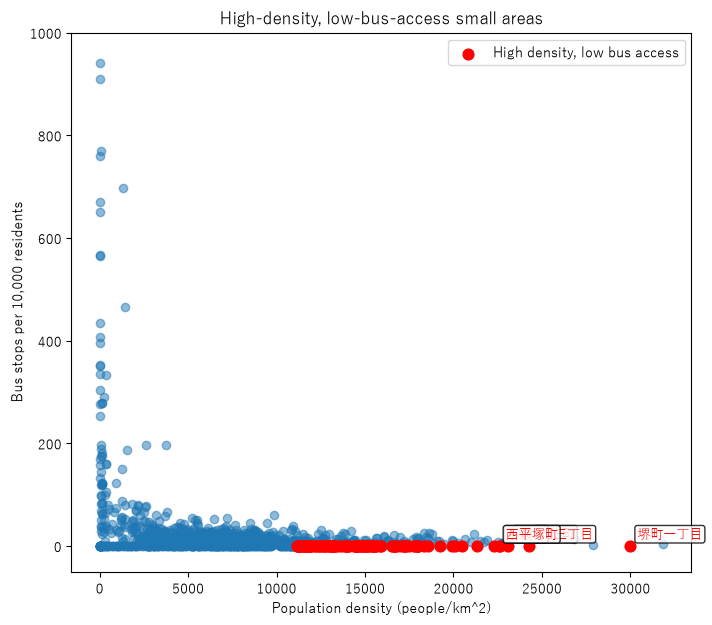

In [33]:
plt.figure(figsize=(8, 7))  # figure size / 그래프 크기 설정

# scatter every small area: population density vs. bus accessibility
# 전체 소지역 산점도 그리기 (인구밀도 vs 버스 접근성)
plt.scatter(
    gdf_map["pop_density"],   # x: population density / x축: 인구밀도
    gdf_map["bus_per_10k"],   # y: bus stops per 10k residents / y축: 인구 1만명당 버스 정류장 수
    alpha=0.5,
)

# threshold definitions
# 기준값 설정
high_density = gdf_map["pop_density"].quantile(0.8)   # top 20% population density / 인구밀도 상위 20% 기준값
low_bus      = gdf_map["bus_per_10k"].quantile(0.1)    # bottom 10% bus accessibility / 버스 접근성 하위 10% 기준값

# candidate underserved areas: high density AND low bus access
# 취약 후보 지역 선택: 인구밀도는 높고 + 버스 접근성은 낮은 소지역
target2 = gdf_map[
    (gdf_map["pop_density"] >= high_density) &
    (gdf_map["bus_per_10k"] <= low_bus)
]

# highlight the candidates in red
# 취약 지역만 빨간색으로 강조 표시
plt.scatter(
    target2["pop_density"],
    target2["bus_per_10k"],
    color="red",
    s=60,
    label="High density, low bus access",
)

print(f"{len(target2)} small areas match both thresholds -- too many to label individually")
print(f"두 기준을 모두 만족하는 소지역 {len(target2)}곳 -- 전부 라벨링하기엔 너무 많음")

# label only the 5 most extreme (highest density) candidates, or the plot
# turns into unreadable overlapping text
# 가장 극단적인(밀도가 가장 높은) 5곳만 라벨링한다 -- 전부 표시하면 텍스트가
# 겹쳐 읽을 수 없다
for _, row in target2.nlargest(5, "pop_density").iterrows():
    plt.annotate(
        row["region_nm"],
        (row["pop_density"], row["bus_per_10k"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        color="red",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.8),
    )

plt.ylim(-50, 1000)  # clip past the small-denominator outliers, same as the previous plot
                       # 이전 그래프와 마찬가지로 소분모 이상치 너머는 보이는 범위에서 제외
plt.xlabel("Population density (people/km^2)")
plt.ylabel("Bus stops per 10,000 residents")
plt.title("High-density, low-bus-access small areas")
plt.legend()
plt.show()